# 01 — Autoencoder deterministico su rappresentazioni STFT

In questo notebook viene addestrato un autoencoder convoluzionale 2D per ricostruire rappresentazioni spettrali pulite a partire da segnali audio contaminati da rumore.
L’obiettivo è verificare la capacità dell’architettura di preservare l’informazione rilevante del segnale prima di introdurre la componente probabilistica del Variational Autoencoder.


## 1. Librerie e configurazione


In [1]:
from pathlib import Path
import wave as waveio

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchaudio

from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAMPLE_RATE = 8000
N_SAMPLES = 8000

N_FFT = 256
HOP_LENGTH = 64

SPEC_H = 128
SPEC_W = 128

LATENT_DIM = 128
BATCH_SIZE = 64
EPOCHS = 12
NOISE_STD = 0.05

# Poca importanza al padding, ma non zero:
# vogliamo comunque imparare a tornare al silenzio.
PADDING_WEIGHT = 0.10

print("device:", device)


device: cpu


In [2]:
from pathlib import Path

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

## 2. Preparazione del dataset FSDD


In [3]:
recordings_dir = Path("audio_data/free-spoken-digit-dataset-1.0.10/recordings")
wav_files = sorted(recordings_dir.glob("*.wav"))

if len(wav_files) == 0:
    raise FileNotFoundError("Dataset non trovato. Esegui prima lo Step 1.")

def parse_name(path):
    digit, speaker, index = path.stem.split("_")
    return int(digit), speaker, int(index)

def load_fixed_audio(path):
    with waveio.open(str(path), "rb") as f:
        sr = f.getframerate()
        channels = f.getnchannels()
        frames = f.readframes(f.getnframes())

    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0

    if channels > 1:
        audio = audio.reshape(-1, channels).mean(axis=1)

    waveform = torch.tensor(audio).unsqueeze(0)

    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(
            waveform, sr, SAMPLE_RATE
        )

    valid_length = min(waveform.shape[1], N_SAMPLES)

    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(
            waveform,
            (0, N_SAMPLES - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :N_SAMPLES]

    mask = torch.zeros_like(waveform)
    mask[:, :valid_length] = 1.0

    return waveform, mask, valid_length

train_files, test_files = [], []

for path in wav_files:
    _, _, idx = parse_name(path)

    if idx <= 4:
        test_files.append(path)
    else:
        train_files.append(path)

print("Train:", len(train_files))
print("Test:", len(test_files))


Train: 2700
Test: 300


## 3. Rappresentazione STFT dei segnali


In [4]:
window = torch.hann_window(N_FFT)

def stft_complex(x):
    return torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    )

def crop_logmag(logmag):
    logmag = logmag[:SPEC_H, :]

    if logmag.shape[1] < SPEC_W:
        logmag = F.pad(
            logmag,
            (0, SPEC_W - logmag.shape[1])
        )
    else:
        logmag = logmag[:, :SPEC_W]

    return logmag

def frame_weights(valid_length):
    # Numero approssimativo di frame realmente occupati dal parlato
    valid_frames = int(np.ceil(valid_length / HOP_LENGTH)) + 1
    valid_frames = min(valid_frames, SPEC_W)

    w = torch.full(
        (1, SPEC_H, SPEC_W),
        PADDING_WEIGHT,
        dtype=torch.float32
    )
    w[:, :, :valid_frames] = 1.0

    return w


## 4. Normalizzazione delle rappresentazioni spettrali

Normalizziamo i log-spettrogrammi con media e deviazione standard calcolate **solo sul training set**.
Questo evita che il decoder debba lavorare con valori su scale molto diverse.


In [5]:
sum_x = 0.0
sum_x2 = 0.0
count_values = 0

for path in train_files:
    clean, _, _ = load_fixed_audio(path)

    X = stft_complex(clean)
    logmag = crop_logmag(torch.log1p(X.abs()))

    sum_x += logmag.sum().item()
    sum_x2 += (logmag ** 2).sum().item()
    count_values += logmag.numel()

SPEC_MEAN = sum_x / count_values
variance = sum_x2 / count_values - SPEC_MEAN ** 2
SPEC_STD = max(variance, 1e-8) ** 0.5

print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD :", SPEC_STD)


SPEC_MEAN: 0.04547776059049216
SPEC_STD : 0.16703430628401916


## 5. Costruzione delle coppie rumoroso–pulito


In [6]:
class SpectrogramDataset(Dataset):
    def __init__(self, files, noise_std=NOISE_STD):
        self.files = files
        self.noise_std = noise_std

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        clean, mask, valid_length = load_fixed_audio(self.files[i])

        g = torch.Generator().manual_seed(10000 + i)
        noise = torch.randn(clean.shape, generator=g)

        noisy = clean + self.noise_std * noise * mask
        noisy = torch.clamp(noisy, -1.0, 1.0)

        clean_stft = stft_complex(clean)
        noisy_stft = stft_complex(noisy)

        clean_logmag = crop_logmag(
            torch.log1p(clean_stft.abs())
        )
        noisy_logmag = crop_logmag(
            torch.log1p(noisy_stft.abs())
        )

        clean_img = (
            (clean_logmag - SPEC_MEAN) / SPEC_STD
        ).unsqueeze(0)

        noisy_img = (
            (noisy_logmag - SPEC_MEAN) / SPEC_STD
        ).unsqueeze(0)

        weights = frame_weights(valid_length)

        digit, _, _ = parse_name(self.files[i])

        return noisy_img, clean_img, weights, digit

train_loader = DataLoader(
    SpectrogramDataset(train_files),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    SpectrogramDataset(test_files),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Dataset pronto")


Dataset pronto


## 6. Architettura dell’autoencoder convoluzionale


In [7]:
class STFTAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),    # 128 -> 64
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),   # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 32 -> 16
            nn.ReLU()
        )

        self.fc_encode = nn.Linear(
            128 * 16 * 16,
            LATENT_DIM
        )

        self.fc_decode = nn.Linear(
            LATENT_DIM,
            128 * 16 * 16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, 4, 2, 1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, 4, 2, 1
            )
            # Nessuna Softplus:
            # lavoriamo su dati standardizzati.
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_encode(h)

    def decode(self, z):
        h = self.fc_decode(z).view(
            -1, 128, 16, 16
        )
        return self.decoder(h)

    def forward(self, x):
        return self.decode(self.encode(x))

model = STFTAutoencoder().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Modello creato")


Modello creato


## 7. Funzione di perdita pesata


In [8]:
def weighted_mse(recon, target, weights):
    error = (recon - target) ** 2

    numerator = (error * weights).sum(
        dim=(1, 2, 3)
    )
    denominator = weights.sum(
        dim=(1, 2, 3)
    ).clamp_min(1.0)

    return numerator / denominator


## 8. Addestramento dell’autoencoder


In [9]:
for epoch in range(1, EPOCHS + 1):
    model.train()

    total_loss = 0.0
    count = 0

    for noisy_img, clean_img, weights, _ in train_loader:
        noisy_img = noisy_img.to(device)
        clean_img = clean_img.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        recon = model(noisy_img)

        loss_per_example = weighted_mse(
            recon,
            clean_img,
            weights
        )

        loss = loss_per_example.mean()

        loss.backward()
        optimizer.step()

        batch = clean_img.size(0)

        total_loss += loss.item() * batch
        count += batch

    print(
        f"Epoch {epoch:02d} | "
        f"weighted MSE={total_loss/count:.5f}"
    )


Epoch 01 | weighted MSE=1.13732
Epoch 02 | weighted MSE=0.70303
Epoch 03 | weighted MSE=0.57660
Epoch 04 | weighted MSE=0.48867
Epoch 05 | weighted MSE=0.42878
Epoch 06 | weighted MSE=0.37288
Epoch 07 | weighted MSE=0.32795
Epoch 08 | weighted MSE=0.29717
Epoch 09 | weighted MSE=0.27522
Epoch 10 | weighted MSE=0.26361
Epoch 11 | weighted MSE=0.23937
Epoch 12 | weighted MSE=0.22435


## 9. Valutazione sul test set


In [10]:
model.eval()

total_loss = 0.0
count = 0

with torch.no_grad():
    for noisy_img, clean_img, weights, _ in test_loader:
        noisy_img = noisy_img.to(device)
        clean_img = clean_img.to(device)
        weights = weights.to(device)

        recon = model(noisy_img)

        loss = weighted_mse(
            recon,
            clean_img,
            weights
        )

        total_loss += loss.sum().item()
        count += clean_img.size(0)

print(
    "Test weighted log-STFT MSE:",
    total_loss / count
)


Test weighted log-STFT MSE: 0.2615232563018799


## 10. Ricostruzione di un segnale di esempio


In [11]:
example_path = test_files[0]

clean, mask, valid_length = load_fixed_audio(
    example_path
)

g = torch.Generator().manual_seed(999)
noise = torch.randn(clean.shape, generator=g)

noisy = torch.clamp(
    clean + NOISE_STD * noise * mask,
    -1.0,
    1.0
)

clean_stft = stft_complex(clean)
noisy_stft = stft_complex(noisy)

noisy_logmag = crop_logmag(
    torch.log1p(noisy_stft.abs())
)

noisy_img = (
    (noisy_logmag - SPEC_MEAN) / SPEC_STD
).unsqueeze(0)

model.eval()

with torch.no_grad():
    recon_norm = model(
        noisy_img.unsqueeze(0).to(device)
    ).cpu().squeeze(0)

# Torniamo dal dominio standardizzato al log-magnitude
recon_logmag = (
    recon_norm.squeeze(0) * SPEC_STD
    + SPEC_MEAN
)

recon_logmag = torch.clamp(
    recon_logmag,
    min=0.0,
    max=8.0
)

recon_mag_128 = torch.expm1(recon_logmag)

T = noisy_stft.shape[1]
recon_mag_128 = recon_mag_128[:, :T]

# Reinseriamo il 129° bin di frequenza
last_bin = torch.zeros(
    1,
    recon_mag_128.shape[1]
)

recon_mag = torch.cat(
    [recon_mag_128, last_bin],
    dim=0
)

# Ricostruzione onesta: fase rumorosa
noisy_phase = torch.angle(noisy_stft)

recon_complex = (
    recon_mag
    * torch.exp(1j * noisy_phase)
)

reconstructed = torch.istft(
    recon_complex,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=N_FFT,
    window=window,
    length=N_SAMPLES
).unsqueeze(0)

print("File:", example_path.name)

print("ORIGINALE")
display(
    Audio(
        clean.squeeze().numpy(),
        rate=SAMPLE_RATE
    )
)

print("DISTORTO")
display(
    Audio(
        noisy.squeeze().numpy(),
        rate=SAMPLE_RATE
    )
)

print("RICOSTRUITO — AUTOENCODER")
display(
    Audio(
        reconstructed.squeeze().numpy(),
        rate=SAMPLE_RATE
    )
)


File: 0_george_0.wav
ORIGINALE


DISTORTO


RICOSTRUITO — AUTOENCODER


## 11. Confronto delle rappresentazioni spettrali


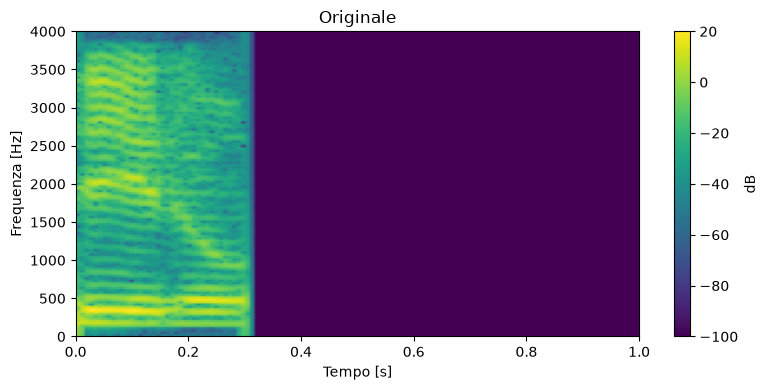

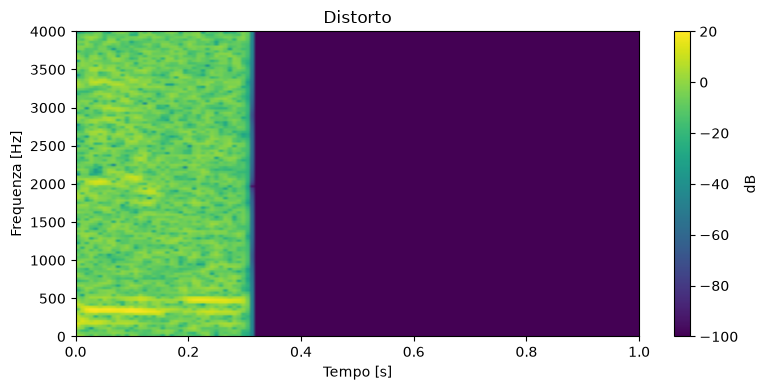

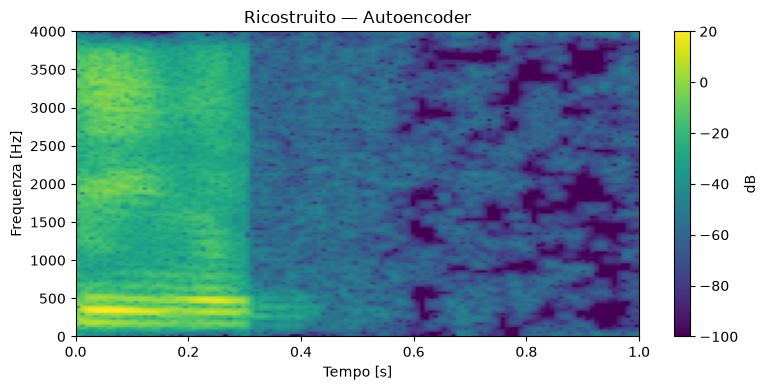

In [12]:
to_db = torchaudio.transforms.AmplitudeToDB(
    stype="power"
)

def power_spec_db(x):
    S = torch.stft(
        x.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    ).abs().pow(2)

    return to_db(S)

spec_clean = power_spec_db(clean)
spec_noisy = power_spec_db(noisy)
spec_recon = power_spec_db(reconstructed)

for title, spec in [
    ("Originale", spec_clean),
    ("Distorto", spec_noisy),
    ("Ricostruito — Autoencoder", spec_recon)
]:
    plt.figure(figsize=(8, 4))

    plt.imshow(
        spec.numpy(),
        origin="lower",
        aspect="auto",
        extent=[0, 1, 0, SAMPLE_RATE / 2],
        vmin=-100,
        vmax=20
    )

    plt.xlabel("Tempo [s]")
    plt.ylabel("Frequenza [Hz]")
    plt.title(title)
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()


## 12. Confronto delle rappresentazioni spettrali


Le prestazioni vengono confrontate sul tratto effettivamente contenente il parlato. Sono considerate metriche nel dominio temporale e spettrale: MSE, SNR, Spectral Convergence e Log-Mel MAE. Valori inferiori di MSE, Spectral Convergence e Log-Mel MAE indicano una migliore ricostruzione, mentre per l’SNR sono preferibili valori più elevati.

In [16]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=64,
    power=2.0
)

def active_mse(clean, estimate, mask):
    num = (
        ((clean - estimate) ** 2) * mask
    ).sum()

    den = mask.sum().clamp_min(1.0)

    return (num / den).item()

def active_snr(clean, estimate, mask):
    signal = ((clean ** 2) * mask).sum()
    error = (
        ((clean - estimate) ** 2) * mask
    ).sum()

    return (
        10 * torch.log10(
            (signal + 1e-12)
            / (error + 1e-12)
        )
    ).item()

def spectral_convergence(clean, estimate, valid_length):
    clean = clean[:, :valid_length]
    estimate = estimate[:, :valid_length]

    S_clean = torch.stft(
        clean.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    ).abs()

    S_est = torch.stft(
        estimate.squeeze(0),
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window=window,
        return_complex=True
    ).abs()

    return (
        torch.linalg.vector_norm(S_est - S_clean)
        / (torch.linalg.vector_norm(S_clean) + 1e-12)
    ).item()

def logmel_mae(clean, estimate, valid_length):
    clean = clean[:, :valid_length]
    estimate = estimate[:, :valid_length]

    M_clean = mel_transform(clean)
    M_est = mel_transform(estimate)

    L_clean = 10 * torch.log10(M_clean + 1e-10)
    L_est = 10 * torch.log10(M_est + 1e-10)

    return torch.mean(
        torch.abs(L_est - L_clean)
    ).item()

print("DISTORTO")
print(
    "MSE:",
    active_mse(clean, noisy, mask)
)
print(
    "SNR:",
    active_snr(clean, noisy, mask)
)
print(
    "SpecConv:",
    spectral_convergence(clean, noisy, valid_length)
)
print(
    "LogMelMAE:",
    logmel_mae(clean, noisy, valid_length))

print("\nRICOSTRUITO — AUTOENCODER")
print(
    "MSE:",
    active_mse(clean, reconstructed, mask)
)
print(
    "SNR:",
    active_snr(clean, reconstructed, mask)
)
print(
    "SpecConv:",
    spectral_convergence(clean, reconstructed, valid_length)
)

print(
    "LogMelMAE:",
    logmel_mae(
    clean,
    reconstructed,
    valid_length
    )
)


DISTORTO
MSE: 0.0025523481890559196
SNR: 4.905676364898682
SpecConv: 0.48979777097702026
LogMelMAE: 12.959388732910156

RICOSTRUITO — AUTOENCODER
MSE: 0.0016377755673602223
SNR: 6.832531929016113
SpecConv: 0.41357457637786865
LogMelMAE: 5.95895528793335


In [14]:
checkpoint_path = CHECKPOINT_DIR / "stft_autoencoder.pt"
torch.save(model.state_dict(), checkpoint_path)
print("Checkpoint salvato:", checkpoint_path)

Checkpoint salvato: checkpoints\stft_autoencoder.pt


# Conclusioni

L’autoencoder migliora la ricostruzione del segnale rumoroso sia nel dominio temporale sia in quello spettrale. Il modello addestrato costituisce quindi una base stabile per l’inizializzazione del VAE utilizzato nelle successive analisi Rate–Distortion.
